# Comparing Marani* and Marani-Inspired Models

- **Summary**: This document compares the original method from [Marani et al. (2021)](https://doi.org/10.1073/pnas.2105482118) and the Marani-inspired method for modeling the exceedance probabilities of respiratory viral epidemics. 

- **Data Required:** `epidemics_marani_240816.xlsx`

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Sep 2, 2024

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.integrate import quad
from scipy.stats import genpareto
from scipy.optimize import minimize

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## 0. Prepare respiratory viral epidemic data

In [2]:
## Read epidemic data from Marani et al. 
df = pd.read_excel("data/epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)

## Subset to respiratory viral epidemics
df_resp_viral = df[df['disease'].isin(['influenza', 'covid-19', 'mers', 'sars'])
                  ].reset_index(drop=True)


In [3]:
## Display all respiratory viral epidemics between 1500-present
# df_resp_viral

## 1. Set up exceedance probabilities from Madhav

In [4]:
## Create Madhav exceedance
severity = [0.001, 0.002, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]
exceedance = [0.2, 0.1, 0.05, 0.02857, 0.02, 0.01, 0.005, 0.003, 0.002, 0.0015, 0.001]

df_madhav = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Save to exceedance results folder
df_madhav.to_excel("exceedance_results/madhav_original.xlsx", index=False)


## 2. Calibrate model with Marani* method

**Note:** Unlike Marani et al., we directly model the severity (deaths per population) instead of the intensity (deaths per population per year) of epidemics. We follow their methodology in using data from 1600-1945 to calibrate the generalized Pareto tail, and multiply the arrival rate of all epidemics in the past 20 years (2000-2019) and the probability of an epidemic being severe conditional on arrival during 1600-1945 to obtain the arrival rate of severe epidemics above the threshold of 0.01 SMU. We refer to this as the Marani* method.

In [5]:
## Subset epidemic data to 1600-1945
df_marani_star = df_resp_viral[(df_resp_viral["year_start"] >= 1600) & 
                               (df_resp_viral["year_start"] <= 1945)].reset_index(drop=True)

## Set severity threshold to 0.01 SMU
thresh = 0.01

## Subset to threshold-exceeding respiratory viral epidemics
df_marani_star_exceed = df_marani_star[df_marani_star['severity_smu'] >= thresh].reset_index(drop=True)


In [6]:
## Display Marani* data for GPD
df_marani_star_exceed 

,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,"pandemic, influenza",1781,1782,2,100.0,869840.0,0.114964,1.149637,influenza,viral,droplet,1,0,1,1
1,west washington influenza,1836,1837,2,8.0,1147067.0,0.006974,0.069743,influenza,viral,droplet,1,0,1,0
2,russian flu,1889,1890,2,1310.0,1497480.0,0.874803,8.748030,influenza,viral,droplet,1,0,1,1
3,pandemic spanish flu,1918,1920,3,32000.0,1873300.0,17.082154,170.821545,influenza,viral,droplet,1,0,1,1


In [7]:
## Fit generalized Pareto distribution on extreme epidemics
params_marani_star = genpareto.fit(df_marani_star_exceed['severity_smu'], floc=thresh)

## Print results
print(params_marani_star)

(3.10566988378568, 0.01, 0.6836398044667586)


In [8]:
## Find arrival rate of all epidemics during 2000 to 2019
arrival_all = df_resp_viral[(df_resp_viral['year_start'] >= 2000) & 
                            (df_resp_viral['year_start'] <= 2019)].shape[0] / 20

## Find probability of epidemic exceeding the threshold conditional on arrival
exceed_prob = df_marani_star_exceed.shape[0] / df_marani_star.shape[0]

## Find arrival rate of threshold-exceeding resp viral epidemics
arrival_severe_marani_star = arrival_all * exceed_prob

In [9]:
## Print arrival rate of threshold-exceeding events
print(round(arrival_severe_marani_star, 3))

0.033


In [10]:
## Calculate exceedance probabilities
exceedance = arrival_severe_marani_star * (1 - genpareto.cdf(severity, 
                                                             *params_marani_star))

df_marani_star = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Sort and reset index (optional)
df_marani_star = df_marani_star.sort_values(by='severity', ascending=True)
df_marani_star = df_marani_star.reset_index(drop=True)


In [11]:
## Display exceedance results
df_marani_star

## Save to exceedance results folder
df_marani_star.to_excel("exceedance_results/marani_original_star.xlsx", index=False)


,severity,exceedance
0,0.001,0.033333
1,0.002,0.033333
2,7.200,0.010744
3,28.000,0.006986
4,45.000,0.006001
5,86.000,0.004875
6,150.000,0.004077
7,200.000,0.003717
8,220.000,0.003605
9,250.000,0.003459


## 3. Calibrate our own Marani-inspired method

**Note:** In contrast to the original Marani model, we use the arrival rate of threshold-exceeding epidemics in the past 20 years directly. Also, we use all threshold-exceeding data from 1600-present to calibrate the GPD fit. We actually double the amount of threshold-exceeding epidemics by extending our sample beyond 1945, which further shows severe epidemics are becoming more frequent, and we should take more recent data into consideration

In [12]:
## Subset epidemic data to 1600-present
df_marani_inspired = df_resp_viral[(df_resp_viral["year_start"] >= 1600)].reset_index(drop=True)

## Set severity threshold to 0.01 SMU
thresh = 0.01

## Subset to threshold-exceeding respiratory viral epidemics
df_marani_inspired_exceed = df_marani_inspired[df_marani_inspired['severity_smu'] >= thresh].reset_index(drop=True)


In [13]:
## Display Marani-inspired data for GPD
df_marani_inspired_exceed 

,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,"pandemic, influenza",1781,1782,2,100.0,869840.0,0.114964,1.149637,influenza,viral,droplet,1,0,1,1
1,west washington influenza,1836,1837,2,8.0,1147067.0,0.006974,0.069743,influenza,viral,droplet,1,0,1,0
2,russian flu,1889,1890,2,1310.0,1497480.0,0.874803,8.748030,influenza,viral,droplet,1,0,1,1
3,pandemic spanish flu,1918,1920,3,32000.0,1873300.0,17.082154,170.821545,influenza,viral,droplet,1,0,1,1
4,pandemic of asian flu,1957,1958,2,2000.0,2873306.0,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
5,hong kong flu,1968,1969,2,1000.0,3551599.0,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
6,swine flu,2009,2009,1,284.5,6872767.0,0.041395,0.413953,influenza,viral,droplet,1,0,1,1
7,global covid-19,2019,2024,6,7100.0,7740000.0,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1


In [14]:
## Fit generalized Pareto distribution on extreme epidemics
params_marani_inspired = genpareto.fit(df_marani_inspired_exceed['severity_smu'], floc=thresh)

## Print results
print(params_marani_inspired)

(1.4922657458876962, 0.01, 2.388662322553925)


In [15]:
## Find arrival rate of threshold-exceeding epidemics during 2000 to 2019
arrival_severe_marani_inspired = df_marani_inspired_exceed[(df_marani_inspired_exceed['year_start'] >= 2000) & 
                                                           (df_marani_inspired_exceed['year_start'] <= 2019)
                                                          ].shape[0] / 20


In [16]:
## Print arrival rate of threshold-exceeding events
print(round(arrival_severe_marani_inspired, 3))

0.1


In [17]:
## Calculate exceedance probabilities
exceedance = arrival_severe_marani_inspired * (1 - genpareto.cdf(severity, 
                                                                 *params_marani_inspired))

df_marani_inspired = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Sort and reset index (optional)
df_marani_inspired = df_marani_inspired.sort_values(by='severity', ascending=True)
df_marani_inspired = df_marani_inspired.reset_index(drop=True)

In [18]:
## Display exceedance results
df_marani_inspired

## Save to exceedance results folder
df_marani_inspired.to_excel("exceedance_results/marani_inspired.xlsx", index=False)


,severity,exceedance
0,0.001,0.100000
1,0.002,0.100000
2,7.200,0.031938
3,28.000,0.014160
4,45.000,0.010446
5,86.000,0.006843
6,150.000,0.004738
7,200.000,0.003914
8,220.000,0.003674
9,250.000,0.003374


## 4. Visually compare the Marani* and Marani-inspired methods

<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Epidemic Severity (SMU, or deaths per 10,000 people)')

Text(0, 0.5, 'Annual Exceedance Probability')

Text(0.5, 1.0, 'Exceedance Probability of Respiratory Viral Epidemics')

(0.0001, 1.0)

(0.01, 1000.0)

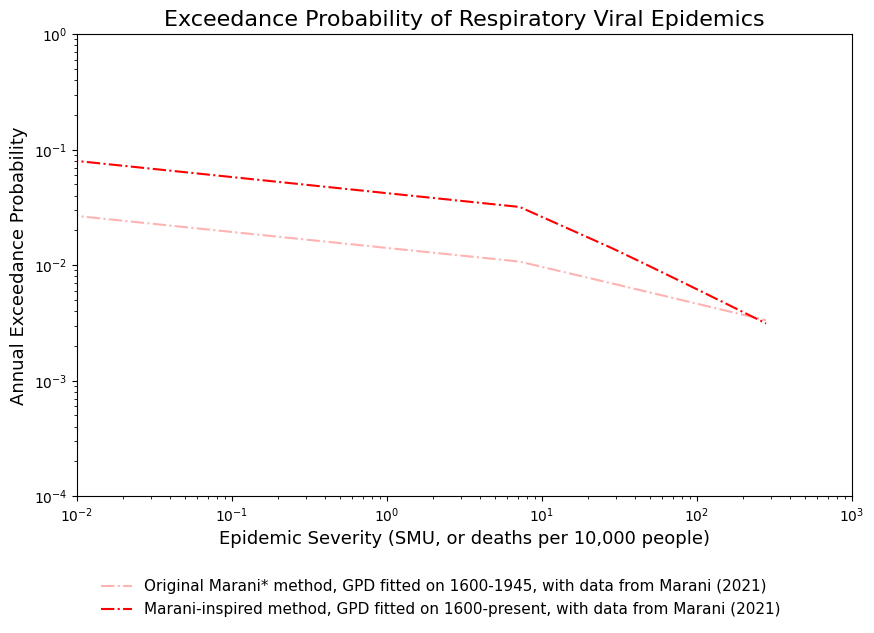

In [19]:
## Plot comparison across Marani* and Marani-inspired methods
plt.figure(figsize=(10, 6))

## Plot for Marani*
plt.plot(df_marani_star['severity'], df_marani_star['exceedance'], 
         color='red', linestyle='-.', alpha=0.3,
         label='Original Marani* method, GPD fitted on 1600-1945, with data from Marani (2021)')

## Plot for Marani-inspired
plt.plot(df_marani_inspired['severity'], df_marani_inspired['exceedance'], 
         color='red', linestyle='-.', alpha=1,
         label='Marani-inspired method, GPD fitted on 1600-present, with data from Marani (2021)')

## Add labels and title
plt.xlabel('Epidemic Severity (SMU, or deaths per 10,000 people)', fontsize=13)
plt.ylabel('Annual Exceedance Probability', fontsize=13)
plt.title('Exceedance Probability of Respiratory Viral Epidemics', fontsize=16)

## Set y-axis scale and limits
plt.yscale('log')
plt.ylim(1e-4, 1e0)

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-2, 1e3)
# plt.xlim(0, 300)

## Adding legend below the plot in 1 column without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=1, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
plt.savefig('graphs/05_resp_viral_marani_comp.jpg', dpi=400, bbox_inches = 'tight')

## Display
plt.show()


## 5. Calibrate original Bernstein method

In [20]:
## Subset epidemics to those with observable severities
df_resp_viral_known = df_resp_viral[df_resp_viral['death_thousand'] > 0
                                   ].reset_index(drop=True)

## Subset epidemics to those in the last century
df_resp_viral_known = df_resp_viral_known[
                        df_resp_viral_known['year_start'] > 1900
                                        ].reset_index(drop=True)

## Display subsetted data
df_resp_viral_known


,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,pandemic spanish flu,1918,1920,3,32000.000,1.873300e+06,17.082154,170.821545,influenza,viral,droplet,1,0,1,1
1,"salomon islands, ontong java",1926,1926,1,0.033,2.020467e+06,0.000016,0.000163,influenza,viral,droplet,1,0,1,0
2,pandemic of asian flu,1957,1958,2,2000.000,2.873306e+06,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
3,hong kong flu,1968,1969,2,1000.000,3.551599e+06,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
4,papua new guinea,1969,1970,2,3.000,3.625681e+06,0.000827,0.008274,influenza,viral,droplet,1,0,1,0
5,global sars,2003,2003,1,0.744,6.381185e+06,0.000117,0.001166,sars,viral,droplet,1,0,1,1
6,swine flu,2009,2009,1,284.500,6.872767e+06,0.041395,0.413953,influenza,viral,droplet,1,0,1,1
7,global mers,2012,2017,6,0.659,7.125828e+06,0.000092,0.000925,mers,viral,droplet,1,0,1,1
8,indian swine flu outbreak,2015,2015,1,2.000,7.379797e+06,0.000271,0.002710,influenza,viral,droplet,1,0,1,0
9,global covid-19,2019,2024,6,7100.000,7.740000e+06,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1


In [21]:
## Define extreme severity threshold 
thresh = 10  ## Set to 10 SMU in accordance with Bernstein and Fan

## Define arrival and mean severity of all epidemics
p_a = 8 / 70  ## 8 epidemics in the past 70 years
mu_a = np.mean(df_resp_viral_known['severity_smu']) ## mean severity of all epidemics

## Define arrival and mean severity of extreme epidemics
p_x = 1 / 100  ## 1 extreme epidemic (1918 flu) in 100 years
mu_x = np.mean(df_resp_viral_known['severity_smu'][
    df_resp_viral_known['severity_smu'] >= thresh])  ## mean severity of extreme epidemics


In [22]:
## Find expected annual SMUs of all and extreme outbreaks
s_a = round(p_a * mu_a, 2)  ## expected annual severity of all outbreaks
s_x = round(p_x * mu_x, 2)  ## expected annual severity of extreme outbreaks

## Calibrate 'm'
m = round(1/(s_a), 2)  ## round 'm' to 2 decimals

## Display expected severities
print(f'Expected annual severity of all epidemics: {s_a} SMU')
print(f'Expected annual severity of extreme epidemics: {s_x} SMU')


Expected annual severity of all epidemics: 2.17 SMU
Expected annual severity of extreme epidemics: 1.71 SMU


In [23]:
## Define function to calibrate 'f' with conditional first moment
def calibrate_hyperbolic_f(m, thresh, s_x):
    """
    Calibrate the parameter 'f' for a hyperbolic function from Fan et al. 
    (2018) based on the first moment conditional on exceedance.

    Parameters:
    - m: float, parameter of the hyperbolic model.
    - thresh: float, threshold value for extreme severities.
    - s_x: float, annual expected extreme severity.

    Returns:
    - f_opt: float, the optimal value of 'f' that minimizes the difference 
      between the integral and the conditional first moment.
    """
    
    ## Define integrand for hyperbolic exceedance
    def integrand(s, m, f):
        return (1 + m * (1 - f) * s) ** (-1 - 1 / (1 - f))
    
    ## Define the objective function to minimize
    def objective(f, m, s_x):
        integral, _ = quad(integrand, thresh, np.inf, args=(m, f))
        return (s_x - integral) ** 2
    
    ## Set bounds for 'f'
    bounds = [(-30, -1)]
    
    ## Minimize difference between integral and conditional moment
    ## x0 is the initial guess for 'f'
    result = minimize(objective, x0=-2, args=(m, s_x), bounds=bounds)
    
    ## Print result
    if result.success:
        if result.fun < 1e-08:
            print("Convergence succeeded! :)")
            print(f"Minimized cost value: {result.fun}")
            print(f"Optimal value of f: {round(result.x[0], 2)}")
        else:
            print("Convergence failed. :(")
            print(f"Minimized cost value: {result.fun}")
    else:
        print("Optimization failed. :(")
        print("Objective function value: NA")
    
    ## Return optimal value of 'f'
    f_opt = result.x[0] if result.success else None
    return f_opt

## Example usage:
## m = 0.23
## thresh = 10
## s_x = 2.97
## f = calibrate_hyperbolic_f(m, thresh, s_x)    


In [24]:
## Calibrate 'f'
f = calibrate_hyperbolic_f(m, thresh, s_x) 
f = round(f, 2)  ## round 'f' to 2 decimals

Convergence succeeded! :)
Minimized cost value: 1.8622522723146694e-12
Optimal value of f: -17.58


In [25]:
print(f'Result: m = {m}, f = {f}')

Result: m = 0.46, f = -17.58


In [26]:
## Calculate Bernstein exceedance probabilities
exceedance = [(1 + m * (1 - f) * s)**(-1 - 1/(1 - f)) for s in severity]

## Create dataframe on exceedance probabilities
df_bernstein = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Sort and reset index
df_bernstein = df_bernstein.sort_values(by='severity', ascending=True)
df_bernstein = df_bernstein.reset_index(drop=True)

## Display severities and exceedance probabilities
# df_bernstein

## Save to exceedance results folder
df_bernstein.to_excel("exceedance_results/bernstein_original.xlsx", index=False)


In [27]:
## Calculate return time of epidemics more severe than COVID-19
covid_severity = 9.173127
covid_exceedance_bernstein = (1 + m * (1 - f) * covid_severity)**(-1 - 1/(1 - f))
covid_return_time_bernstein = round(1 / covid_exceedance_bernstein, 2)

## Display return time
print(f'Return time of epidemics more severe than COVID-19: {covid_return_time_bernstein} years')

Return time of epidemics more severe than COVID-19: 100.48 years


## 6. Visually compare against Bernstein and Madhav

<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Epidemic Severity (SMU, or deaths per 10,000 people)')

Text(0, 0.5, 'Annual Exceedance Probability')

Text(0.5, 1.0, 'Exceedance Probability of Respiratory Viral Epidemics')

(0.0001, 1.0)

(0.01, 1000.0)

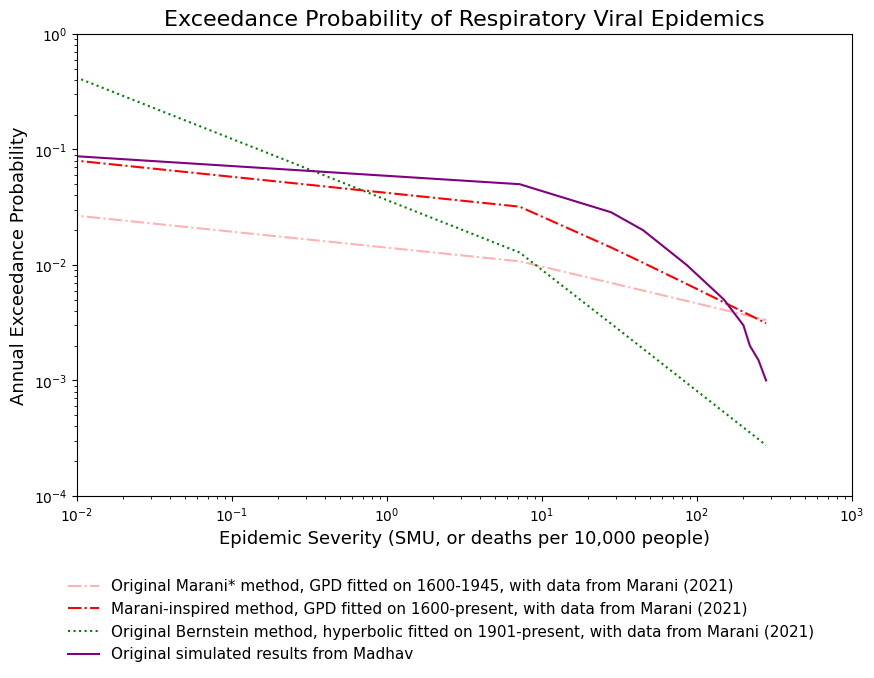

In [28]:
## Plot comparison across Madhav, Marani, and Bernstein-Fan 
plt.figure(figsize=(10, 6))

## Plot for Marani*
plt.plot(df_marani_star['severity'], df_marani_star['exceedance'], 
         color='red', linestyle='-.', alpha=0.3,
         label='Original Marani* method, GPD fitted on 1600-1945, with data from Marani (2021)')

## Plot for Marani-inspired
plt.plot(df_marani_inspired['severity'], df_marani_inspired['exceedance'], 
         color='red', linestyle='-.', alpha=1,
         label='Marani-inspired method, GPD fitted on 1600-present, with data from Marani (2021)')

## Plot for Bernstein 
plt.plot(df_bernstein['severity'], df_bernstein['exceedance'], 
         color='green', linestyle=':', 
         label='Original Bernstein method, hyperbolic fitted on 1901-present, with data from Marani (2021)')

## Plot for Madhav
plt.plot(df_madhav['severity'], df_madhav['exceedance'], 
         color='purple', linestyle='-', label='Original simulated results from Madhav')

## Add labels and title
plt.xlabel('Epidemic Severity (SMU, or deaths per 10,000 people)', fontsize=13)
plt.ylabel('Annual Exceedance Probability', fontsize=13)
plt.title('Exceedance Probability of Respiratory Viral Epidemics', fontsize=16)

## Set y-axis scale and limits
plt.yscale('log')
plt.ylim(1e-4, 1e0)

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-2, 1e3)
# plt.xlim(0, 300)

## Adding legend below the plot in 1 column without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=1, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
plt.savefig('graphs/05_resp_viral_original_and_inspired.jpg', dpi=400, bbox_inches = 'tight')

## Display
plt.show()


**Note:** The original Marani method, which uses the arrival rate of all epidemics and the probability of threshold-exceedance conditional on epidemic arrival during 1600-1945, underestimates the current arrival rate of severe threshold-exceeding respiratory viral epidemics. 